In [53]:
import pandas as pd

In [29]:
tx = pd.read_excel('QVI_transaction_data.xlsx')

In [30]:
tx.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [31]:
dupes = tx[tx.duplicated(keep=False)]
dupes

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
124843,43374,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0
124845,43374,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0


In [32]:
print("Rows before:", len(tx))
tx = tx.drop_duplicates()
print("Rows after:", len(tx))

Rows before: 264836
Rows after: 264835


In [33]:
tx[tx['PROD_QTY'] >= 100]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,43331,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,43605,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [34]:
print("Rows before:", len(tx))
tx = tx[tx['LYLTY_CARD_NBR'] != 226000]
print("Rows after:", len(tx))

Rows before: 264835
Rows after: 264833


In [35]:
salsa_dip_products = [
    'Doritos Salsa       Medium 300g',
    'Doritos Salsa Mild  300g',
    'Old El Paso Salsa   Dip Chnky Tom Ht300g',
    'Old El Paso Salsa   Dip Tomato Med 300g',
    'Old El Paso Salsa   Dip Tomato Mild 300g',
    'Woolworths Medium   Salsa 300g',
    'Woolworths Mild     Salsa 300g',
]

print("Rows before:", len(tx))
tx = tx[~tx['PROD_NAME'].isin(salsa_dip_products)]
print("Rows after:", len(tx))

Rows before: 264833
Rows after: 249667


In [36]:
tx['DATE'] = pd.to_datetime(tx['DATE'], origin='1899-12-30', unit='D')
tx['DATE'].head()

,DATE
0,2018-10-17
1,2019-05-14
2,2019-05-20
3,2018-08-17
4,2018-08-18


In [37]:
print("Earliest date:", tx['DATE'].min())
print("Latest date:", tx['DATE'].max())
print("Number of unique transaction dates:", tx['DATE'].nunique())

Earliest date: 2018-07-01 00:00:00
Latest date: 2019-06-30 00:00:00
Number of unique transaction dates: 364


In [38]:
full_range = pd.date_range(start='2018-07-01', end='2019-06-30', freq='D')
actual_dates = tx['DATE'].unique()
missing_dates = full_range[~full_range.isin(actual_dates)]
missing_dates

DatetimeIndex(['2018-12-25'], dtype='datetime64[ns]', freq='D')

In [39]:
tx['PACK_SIZE_TEST'] = tx['PROD_NAME'].str.extract(r'(\d+)g')[0]
tx[tx['PACK_SIZE_TEST'].isna()]['PROD_NAME'].unique()

array(['Grain Waves Sour    Cream&Chives 210G',
       'Red Rock Deli Sp    Salt & Truffle 150G',
       'Smiths Thinly       Swt Chli&S/Cream175G'], dtype=object)

In [40]:
tx = tx.drop(columns=['PACK_SIZE_TEST'])  # remove our scratch column

tx['PACK_SIZE'] = tx['PROD_NAME'].str.extract(r'(\d+)[gG]')[0].astype(int)
tx[['PROD_NAME', 'PACK_SIZE']].head(10)

,PROD_NAME,PACK_SIZE
0,Natural Chip Compny SeaSalt175g,175
1,CCs Nacho Cheese 175g,175
2,Smiths Crinkle Cut Chips Chicken 170g,170
3,Smiths Chip Thinly S/Cream&Onion 175g,175
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,150
6,Smiths Crinkle Chips Salt & Vinegar 330g,330
7,Grain Waves Sweet Chilli 210g,210
8,Doritos Corn Chip Mexican Jalapeno 150g,150
9,Grain Waves Sour Cream&Chives 210G,210
10,Smiths Crinkle Chips Salt & Vinegar 330g,330


In [41]:
tx['PACK_SIZE'].describe()

,PACK_SIZE
count,249667.000000
mean,175.283490
std,59.146873
min,70.000000
25%,150.000000
50%,170.000000
75%,175.000000
max,380.000000


In [42]:
tx['BRAND'] = tx['PROD_NAME'].str.split(' ').str[0]
tx['BRAND'].unique()

array(['Natural', 'CCs', 'Smiths', 'Kettle', 'Grain', 'Doritos',
       'Twisties', 'WW', 'Thins', 'Burger', 'NCC', 'Cheezels', 'Infzns',
       'Red', 'Pringles', 'Dorito', 'Infuzions', 'Smith', 'GrnWves',
       'Tyrrells', 'Cobs', 'French', 'RRD', 'Tostitos', 'Cheetos',
       'Woolworths', 'Snbts', 'Sunbites'], dtype=object)

In [43]:
brand_fixes = {
    'Red': 'RRD',
    'Smith': 'Smiths',
    'Dorito': 'Doritos',
    'Infzns': 'Infuzions',
    'WW': 'Woolworths',
    'NCC': 'Natural',
    'GrnWves': 'Grain',
    'Snbts': 'Sunbites',
}

tx['BRAND'] = tx['BRAND'].replace(brand_fixes)
tx['BRAND'].unique()

array(['Natural', 'CCs', 'Smiths', 'Kettle', 'Grain', 'Doritos',
       'Twisties', 'Woolworths', 'Thins', 'Burger', 'Cheezels',
       'Infuzions', 'RRD', 'Pringles', 'Tyrrells', 'Cobs', 'French',
       'Tostitos', 'Cheetos', 'Sunbites'], dtype=object)

In [44]:
cust = pd.read_csv('QVI_purchase_behaviour.csv')
print(cust.shape)
print(cust.isnull().sum())
print(cust['LIFESTAGE'].unique())
print(cust['PREMIUM_CUSTOMER'].unique())
print(cust.duplicated().sum())

(72637, 3)
LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64
['YOUNG SINGLES/COUPLES' 'YOUNG FAMILIES' 'OLDER SINGLES/COUPLES'
 'MIDAGE SINGLES/COUPLES' 'NEW FAMILIES' 'OLDER FAMILIES' 'RETIREES']
['Premium' 'Mainstream' 'Budget']
0


In [45]:
print("Transaction rows before merge:", len(tx))
data = pd.merge(tx, cust, on='LYLTY_CARD_NBR', how='left')
print("Merged rows:", len(data))
print(data.isnull().sum())

Transaction rows before merge: 249667
Merged rows: 249667
DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


In [46]:
data.to_csv('QVI_data_cleaned.csv', index=False)
print("Saved:", data.shape)

Saved: (249667, 12)


In [47]:
segment_sales = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()
segment_sales = segment_sales.sort_values('TOT_SALES', ascending=False)
segment_sales

,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES
6,OLDER FAMILIES,Budget,158379.95
19,YOUNG SINGLES/COUPLES,Mainstream,148337.20
13,RETIREES,Mainstream,146328.75
15,YOUNG FAMILIES,Budget,130919.05
9,OLDER SINGLES/COUPLES,Budget,128683.80
10,OLDER SINGLES/COUPLES,Mainstream,125737.10
11,OLDER SINGLES/COUPLES,Premium,124457.05
12,RETIREES,Budget,106606.20
7,OLDER FAMILIES,Mainstream,97280.85
14,RETIREES,Premium,91951.95


In [48]:
segment_customers = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index()
segment_customers.columns = ['LIFESTAGE', 'PREMIUM_CUSTOMER', 'NUM_CUSTOMERS']

segment_summary = pd.merge(segment_sales, segment_customers, on=['LIFESTAGE', 'PREMIUM_CUSTOMER'])
segment_summary['AVG_SALES_PER_CUSTOMER'] = segment_summary['TOT_SALES'] / segment_summary['NUM_CUSTOMERS']
segment_summary = segment_summary.sort_values('AVG_SALES_PER_CUSTOMER', ascending=False)
segment_summary

,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES,NUM_CUSTOMERS,AVG_SALES_PER_CUSTOMER
8,OLDER FAMILIES,Mainstream,97280.85,2796,34.792865
0,OLDER FAMILIES,Budget,158379.95,4622,34.266540
13,OLDER FAMILIES,Premium,75983.00,2240,33.920982
3,YOUNG FAMILIES,Budget,130919.05,3961,33.052020
12,YOUNG FAMILIES,Premium,79249.10,2404,32.965516
10,YOUNG FAMILIES,Mainstream,87227.85,2693,32.390587
6,OLDER SINGLES/COUPLES,Premium,124457.05,4694,26.514071
4,OLDER SINGLES/COUPLES,Budget,128683.80,4864,26.456373
11,MIDAGE SINGLES/COUPLES,Mainstream,85262.75,3302,25.821548
5,OLDER SINGLES/COUPLES,Mainstream,125737.10,4870,25.818706


In [49]:
pack_by_segment = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PACK_SIZE'].mean().reset_index()
pack_by_segment = pack_by_segment.sort_values('PACK_SIZE', ascending=False)
pack_by_segment.head(5)

,LIFESTAGE,PREMIUM_CUSTOMER,PACK_SIZE
19,YOUNG SINGLES/COUPLES,Mainstream,178.112662
1,MIDAGE SINGLES/COUPLES,Mainstream,177.637143
11,OLDER SINGLES/COUPLES,Premium,176.197718
12,RETIREES,Budget,176.140212
14,RETIREES,Premium,176.086999


In [50]:
behaviour_summary = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg(
    NUM_TRANSACTIONS=('TXN_ID', 'count'),
    NUM_CUSTOMERS=('LYLTY_CARD_NBR', 'nunique'),
    AVG_UNITS_PER_TXN=('PROD_QTY', 'mean')
).reset_index()

behaviour_summary['AVG_TXNS_PER_CUSTOMER'] = behaviour_summary['NUM_TRANSACTIONS'] / behaviour_summary['NUM_CUSTOMERS']
behaviour_summary = behaviour_summary.sort_values('AVG_TXNS_PER_CUSTOMER', ascending=False)
behaviour_summary

,LIFESTAGE,PREMIUM_CUSTOMER,NUM_TRANSACTIONS,NUM_CUSTOMERS,AVG_UNITS_PER_TXN,AVG_TXNS_PER_CUSTOMER
7,OLDER FAMILIES,Mainstream,13411,2796,1.948550,4.796495
6,OLDER FAMILIES,Budget,21808,4622,1.945387,4.718304
8,OLDER FAMILIES,Premium,10546,2240,1.945572,4.708036
15,YOUNG FAMILIES,Budget,17995,3961,1.941428,4.543045
17,YOUNG FAMILIES,Premium,10919,2404,1.937540,4.542013
16,YOUNG FAMILIES,Mainstream,12121,2693,1.941259,4.500928
11,OLDER SINGLES/COUPLES,Premium,16741,4694,1.913984,3.566468
9,OLDER SINGLES/COUPLES,Budget,17345,4864,1.914327,3.565995
10,OLDER SINGLES/COUPLES,Mainstream,17276,4870,1.911206,3.547433
1,MIDAGE SINGLES/COUPLES,Mainstream,11200,3302,1.911875,3.391884


In [51]:
top_brand_by_segment = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER', 'BRAND'])['TOT_SALES'].sum().reset_index()
top_brand_by_segment = top_brand_by_segment.sort_values('TOT_SALES', ascending=False).groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).head(1)
top_brand_by_segment

,LIFESTAGE,PREMIUM_CUSTOMER,BRAND,TOT_SALES
389,YOUNG SINGLES/COUPLES,Mainstream,Kettle,35423.6
129,OLDER FAMILIES,Budget,Kettle,32058.0
269,RETIREES,Mainstream,Kettle,31652.4
189,OLDER SINGLES/COUPLES,Budget,Kettle,29066.4
229,OLDER SINGLES/COUPLES,Premium,Kettle,27943.4
209,OLDER SINGLES/COUPLES,Mainstream,Kettle,26852.8
309,YOUNG FAMILIES,Budget,Kettle,26369.6
249,RETIREES,Budget,Kettle,24340.0
289,RETIREES,Premium,Kettle,20922.4
29,MIDAGE SINGLES/COUPLES,Mainstream,Kettle,20231.8


**Data Preparation and Customer Analytics — Initial Findings**

**Data Cleaning**

The transaction dataset (264,836 rows) and customer dataset (72,637 rows) were checked and cleaned prior to analysis:

*   Removed 1 exact duplicate transaction row

*   Excluded loyalty card 226000, which recorded two 200-unit purchases of the same product consistent with a commercial/bulk buyer rather than a retail customer, and would have distorted per-customer averages if retained
*   Removed 7 salsa dip products that had been included in the transaction data despite not being chip products (care was taken to retain chip products that are salsa-flavoured, e.g. "Tomato Salsa" flavour chips)

*   Converted the DATE field from Excel serial format to calendar dates; confirmed the dataset covers 1 July 2018 – 30 June 2019 with no transactions on 25 December 2018 (store closure, not a data error)

*   Engineered two new features from the product name field: PACK_SIZE and BRAND, correcting for case-sensitivity issues (e.g. "175g" vs "175G") and 8 inconsistent brand spellings/abbreviations (e.g. "Dorito" vs "Doritos", "WW" vs "Woolworths")
*   Merged the cleaned transaction and customer datasets on loyalty card number (249,667 rows, zero unmatched records)










**Key Findings**

Total sales are not the same as customer value. Older Families/Budget generated the highest total sales ($158,380), but this reflects segment size as much as spending behaviour.

Families are the highest-value customers per capita. When normalised by number of customers, all six Family segments (Older and Young, across Budget/Mainstream/Premium) rank in the top 6 of 20 segments for average spend per customer (~$32-35), despite Young Singles/Couples/Mainstream being the largest customer base overall (7,930 customers) but ranking near the bottom per customer (18.71).

The driver is purchase frequency, not basket size. Family segments visit ~4.5–4.8 times per year on average, versus 2.4–3.6 for Singles/Couples and Retiree segments. Average units per transaction (1.81–1.95) and average pack size (176–178g) are both essentially flat across all 20 segments ruling out "bigger baskets" or "bigger packs" as explanations for the difference in spend.

Kettle is the dominant brand across every segment (20/20), indicating a stocking baseline rather than a segment-specific targeting opportunity.

**Commercial Recommendation**

The data supports prioritising Family segments (Older and Young, regardless of Budget/Mainstream/Premium tier) for the chip category strategy, with promotional focus on increasing purchase frequency e.g. loyalty or repeat-visit incentives rather than pack-size or premium-tier plays, since neither pack size nor units-per-transaction meaningfully differentiate high-value from low-value segments in this data

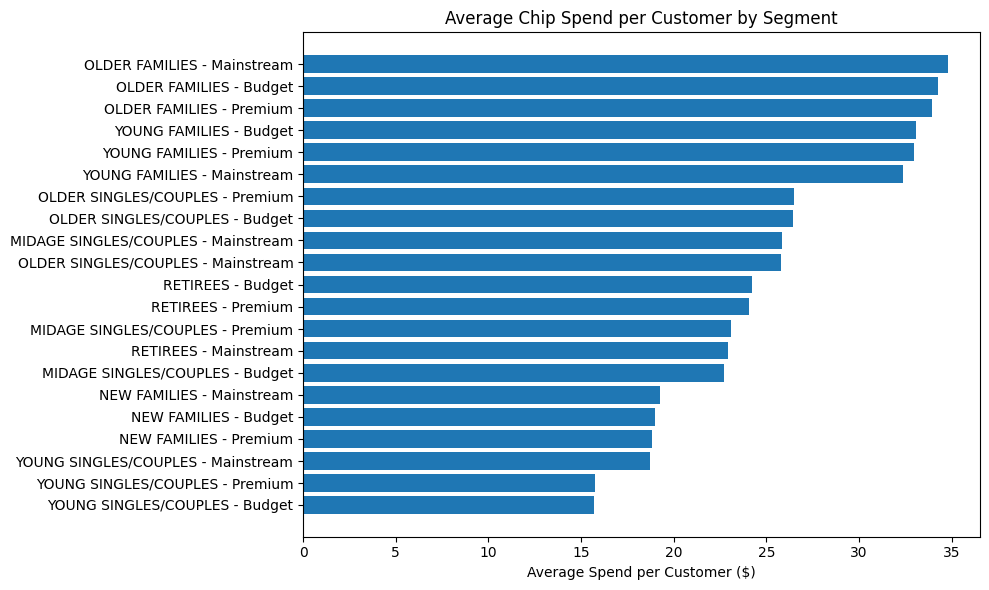

In [54]:
import matplotlib.pyplot as plt

segment_summary['SEGMENT_LABEL'] = segment_summary['LIFESTAGE'] + ' - ' + segment_summary['PREMIUM_CUSTOMER']

plt.figure(figsize=(10, 6))
plt.barh(segment_summary['SEGMENT_LABEL'], segment_summary['AVG_SALES_PER_CUSTOMER'])
plt.xlabel('Average Spend per Customer ($)')
plt.title('Average Chip Spend per Customer by Segment')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()